In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [2]:
BASE     = Path.home() / "Desktop/mold_risk_model"
RAW      = BASE / "data/raw"
RICO_DIR = RAW / "rico"
ITS_DIR  = RAW / "iotsec"
EPW_DIR  = RAW / "epw"
FIG_DIR  = BASE / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Confirm everything exists
for d in [RICO_DIR, ITS_DIR, EPW_DIR]:
    status = "✓" if d.exists() else "✗ MISSING"
    print(f"{status}  {d}")

✓  /Users/arnavchavan/Desktop/mold_risk_model/data/raw/rico
✓  /Users/arnavchavan/Desktop/mold_risk_model/data/raw/iotsec
✓  /Users/arnavchavan/Desktop/mold_risk_model/data/raw/epw


In [3]:
rico_files = sorted(RICO_DIR.glob("*.hdf"))
iotsec_files = {
    loc: sorted((ITS_DIR / f"location_{loc}").glob("*.csv"))
    for loc in ["A", "B", "C"]
}
epw_files = sorted(EPW_DIR.glob("*.epw"))

print(f"RICO files     : {len(rico_files)}")
for f in rico_files:
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")

print(f"\nIoTsec files:")
for loc, files in iotsec_files.items():
    print(f"  Location {loc}  : {len(files)} measurements")

print(f"\nEPW files      : {len(epw_files)}")
for f in epw_files:
    print(f"  {f.name}")

RICO files     : 5
  RICO_Acquisition_1_07-2023.hdf  (17.8 MB)
  RICO_Acquisition_2_10-2023.hdf  (10.5 MB)
  RICO_Acquisition_3_01-2024.hdf  (3.8 MB)
  RICO_Acquisition_4_02-2024.hdf  (27.2 MB)
  RICO_Acquisition_5_05-2024.hdf  (18.3 MB)

IoTsec files:
  Location A  : 60 measurements
  Location B  : 44 measurements
  Location C  : 40 measurements

EPW files      : 4
  USA_CA_Port.Chicago.724958_TMYx.2011-2025.epw
  USA_FL_Miami.Intl.AP.722020_TMY3.epw
  USA_LA_New.Orleans-NAS.JRB.New.Orleans-Callender.Field.722316_US.Normals.2006-2020.epw
  USA_TX_Houston-Bush.Intercontinental.AP.722430_TMYx.epw


In [4]:
# Start with Acquisition 3 (January - highest mold risk season)
rico_path = RICO_DIR / "RICO_Acquisition_3_01-2024.hdf"

with h5py.File(rico_path, "r") as f:
    # Print top-level structure
    print("Keys:", list(f.keys())[:10], "...")
    print("Total datasets:", len(f.keys()))

    def pick_first_dataset(obj):
        if isinstance(obj, h5py.Dataset):
            return obj, obj.name
        if isinstance(obj, h5py.Group):
            first_path = None

            def _visitor(name, item):
                nonlocal first_path
                if first_path is None and isinstance(item, h5py.Dataset):
                    first_path = name

            obj.visititems(_visitor)
            if first_path is None:
                return None, None
            ds = obj[first_path]
            full_path = f"{obj.name}/{first_path}".replace("//", "/")
            return ds, full_path
        return None, None

    # Load first trial
    numeric_keys = sorted([k for k in f.keys() if str(k).isdigit()], key=lambda x: int(x))
    first_key = numeric_keys[0] if numeric_keys else sorted(f.keys())[0]
    if not numeric_keys:
        print("No numeric trial keys found; using first key:", first_key)

    target = f[first_key]
    ds, ds_path = pick_first_dataset(target)
    if ds is None:
        raise ValueError(f"No dataset found under key '{first_key}'.")

    sample = pd.DataFrame(ds[:])
    print(f"\nTrial '{first_key}' dataset '{ds_path}' shape: {ds.shape}")
    print(f"Dtype: {ds.dtype}")

Keys: ['all'] ...
Total datasets: 1
No numeric trial keys found; using first key: all

Trial 'all' dataset '/all/axis0' shape: (82,)
Dtype: |S23


In [5]:
# RICO stores data differently from finger_data - let's check if it uses
# named columns or raw arrays
with h5py.File(rico_path, "r") as f:
    def pick_first_dataset(obj):
        if isinstance(obj, h5py.Dataset):
            return obj, obj.name
        if isinstance(obj, h5py.Group):
            first_path = None

            def _visitor(name, item):
                nonlocal first_path
                if first_path is None and isinstance(item, h5py.Dataset):
                    first_path = name

            obj.visititems(_visitor)
            if first_path is None:
                return None, None
            ds = obj[first_path]
            full_path = f"{obj.name}/{first_path}".replace("//", "/")
            return ds, full_path
        return None, None

    numeric_keys = sorted([k for k in f.keys() if str(k).isdigit()], key=lambda x: int(x))
    keys = numeric_keys if numeric_keys else sorted(f.keys())
    if not numeric_keys:
        print("No numeric trial keys found; using first key:", keys[0])

    target = f[keys[0]]
    ds, ds_path = pick_first_dataset(target)
    if ds is None:
        raise ValueError(f"No dataset found under key '{keys[0]}'.")

    print("Dataset path:", ds_path)
    print("Dataset shape:", ds.shape)
    print("Dtype:", ds.dtype)
    print("Attrs:", dict(ds.attrs))

No numeric trial keys found; using first key: all
Dataset path: /all/axis0
Dataset shape: (82,)
Dtype: |S23
Attrs: {'CLASS': np.bytes_(b'ARRAY'), 'FLAVOR': np.bytes_(b'numpy'), 'TITLE': Empty(dtype=dtype('S1')), 'VERSION': np.bytes_(b'2.4'), 'kind': np.bytes_(b'string'), 'name': np.bytes_(b'Index'), 'transposed': np.uint8(1)}


In [6]:
def load_rico(path):
    """Load all trials from one RICO HDF file.
    Returns dict: {trial_id: DataFrame or array}
    """
    def pick_first_dataset(obj):
        if isinstance(obj, h5py.Dataset):
            return obj
        if isinstance(obj, h5py.Group):
            first_path = None

            def _visitor(name, item):
                nonlocal first_path
                if first_path is None and isinstance(item, h5py.Dataset):
                    first_path = name

            obj.visititems(_visitor)
            if first_path is None:
                return None
            return obj[first_path]
        return None

    data = {}
    with h5py.File(path, "r") as f:
        numeric_keys = [k for k in f.keys() if str(k).isdigit()]
        keys = sorted(numeric_keys, key=lambda x: int(x)) if numeric_keys else sorted(f.keys())
        for k in keys:
            # Some keys (e.g. "all") can be groups, not datasets.
            target = f[k]
            ds = pick_first_dataset(target)
            if ds is None:
                continue

            key_id = int(k) if str(k).isdigit() else k
            if ds.dtype.names:
                # Structured array - convert to DataFrame
                data[key_id] = pd.DataFrame({
                    col: ds[col][:] for col in ds.dtype.names
                })
            else:
                data[key_id] = ds[:]
    return data

rico3 = load_rico(rico_path)
print(f"Loaded {len(rico3)} trials from Acquisition 3")
print(f"Trial 0 type: {type(list(rico3.values())[0])}")

sample_trial = list(rico3.values())[0]
if isinstance(sample_trial, pd.DataFrame):
    print(sample_trial.head())
    print("\nColumns:", list(sample_trial.columns))
else:
    arr = np.asarray(sample_trial)
    print(f"Array shape: {arr.shape}")
    if arr.ndim == 1:
        print("First 10 values:\n", arr[:10])
    else:
        print("First 3 rows, first 5 cols:\n", arr[:3, :5])

Loaded 1 trials from Acquisition 3
Trial 0 type: <class 'numpy.ndarray'>
Array shape: (82,)
First 10 values:
 [b'Acquisition Phase' b'Scheduler Step' b'Flag' b'pid.EC3.setpoint'
 b'pid.SB43.setpoint' b'pid.SB46.setpoint' b'pid.SB47.setpoint'
 b'B.ASTRHT2.H' b'B.ASTRHT2.S' b'B.ASTRHT2.T']


In [7]:
# Depending on RICO structure, identify which rows/columns are temp and RH
sample = list(rico3.values())[0]

if isinstance(sample, pd.DataFrame):
    # Search column names for temp/humidity keywords
    cols = sample.columns.str.lower()
    temp_cols = [c for c in sample.columns if any(k in c.lower() 
                 for k in ['temp', 'tmp', 't_', '_t', 'temperature'])]
    rh_cols   = [c for c in sample.columns if any(k in c.lower() 
                 for k in ['rh', 'humid', 'moisture', 'hum'])]
    print("Potential temp columns:", temp_cols[:10])
    print("Potential RH columns  :", rh_cols[:10])
else:
    # Raw array - print stats per row to identify temp/RH by value range
    arr = np.asarray(sample)
    if arr.dtype.kind in ("S", "U", "O"):
        arr_num = pd.to_numeric(arr.ravel(), errors="coerce").reshape(arr.shape)
    else:
        arr_num = arr.astype(float, copy=False)

    if not np.isfinite(arr_num).any():
        print("Array appears non-numeric; dtype:", arr.dtype)
    elif arr_num.ndim == 1:
        vals = arr_num[np.isfinite(arr_num)]
        print("1D array stats (numeric values only):")
        print(f"Min: {vals.min():.2f}  Max: {vals.max():.2f}  "
              f"Mean: {vals.mean():.2f}  Std: {vals.std():.2f}")
    else:
        print("Row-by-row stats (looking for temp ~15-35°C, RH ~30-90%):")
        print(f"{'Row':>5} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8}")
        for i in range(min(20, arr_num.shape[0])):
            row = arr_num[i]
            row_vals = row[np.isfinite(row)]
            if row_vals.size == 0:
                print(f"{i:>5} {'nan':>8} {'nan':>8} {'nan':>8} {'nan':>8}")
            else:
                print(f"{i:>5} {row_vals.min():>8.2f} {row_vals.max():>8.2f} "
                      f"{row_vals.mean():>8.2f} {row_vals.std():>8.2f}")

Array appears non-numeric; dtype: |S23


In [8]:
iotsec_sample = pd.read_csv(
    ITS_DIR / "location_A" / "measurement01.csv",
    header=None,
    names=["EID","AbsT","RelT","NID","Temp","RelH",
           "L1","L2","Occ","Act","Door","Win"]
)

print("Shape:", iotsec_sample.shape)
print("\nFirst 5 rows:")
print(iotsec_sample.head())
print("\nData types:")
print(iotsec_sample.dtypes)
print("\nBasic stats:")
print(iotsec_sample[["Temp","RelH"]].describe())

Shape: (8184, 12)

First 5 rows:
   EID           AbsT  RelT  NID   Temp   RelH      L1      L2  Occ  Act  \
0    1  1458031648545     1    1 20.480 42.332 185.710 492.200    0    0   
1    2  1458031648645     1    4 20.730 39.983 214.290 657.800    0    0   
2    3  1458031648795     1    3 20.480 38.687 197.140 542.800    0    0   
3    4  1458031651038     3    2 20.890 40.712 174.290 552.000    0    0   
4    5  1458031652010     4    4 20.730 39.983 211.430 653.200    0    0   

   Door  Win  
0     0    0  
1     0    0  
2     0    0  
3     0    0  
4     0    0  

Data types:
EID       int64
AbsT      int64
RelT      int64
NID       int64
Temp    float64
RelH    float64
L1      float64
L2      float64
Occ       int64
Act       int64
Door      int64
Win       int64
dtype: object

Basic stats:
          Temp     RelH
count 8184.000 8184.000
mean    20.904   42.584
std      0.229    2.217
min     20.460   38.606
25%     20.750   40.834
50%     20.870   42.494
75%     21.120   44

In [9]:
def load_iotsec_all(iotsec_dir):
    cols = ["EID","AbsT","RelT","NID","Temp","RelH",
            "L1","L2","Occ","Act","Door","Win"]
    frames = []
    for loc in ["A","B","C"]:
        loc_dir = iotsec_dir / f"location_{loc}"
        for f in sorted(loc_dir.glob("*.csv")):
            df = pd.read_csv(f, header=None, names=cols)
            df["location"] = loc
            df["measurement"] = f.stem  # e.g. "measurement01"
            frames.append(df)
    return pd.concat(frames, ignore_index=True)

iotsec_all = load_iotsec_all(ITS_DIR)

print(f"Total rows    : {len(iotsec_all):,}")
print(f"Locations     : {iotsec_all['location'].unique()}")
print(f"Temp range    : {iotsec_all['Temp'].min():.1f} – "
      f"{iotsec_all['Temp'].max():.1f} °C")
print(f"RH range      : {iotsec_all['RelH'].min():.1f} – "
      f"{iotsec_all['RelH'].max():.1f} %")
print(f"Missing values:\n{iotsec_all[['Temp','RelH']].isnull().sum()}")

Total rows    : 540,364
Locations     : <ArrowStringArray>
['A', 'B', 'C']
Length: 3, dtype: str
Temp range    : 20.4 – 25.5 °C
RH range      : 34.5 – 65.4 %
Missing values:
Temp    0
RelH    0
dtype: int64



USA_CA_Port.Chicago.
  Rows: 8760  |  Temp: 0–36°C  |  RH: 10–100%

USA_FL_Miami.Intl.AP
  Rows: 8760  |  Temp: 5–36°C  |  RH: 20–100%

USA_LA_New.Orleans-N
  Rows: 8760  |  Temp: 8–31°C  |  RH: 51–93%

USA_TX_Houston-Bush.
  Rows: 8760  |  Temp: -3–37°C  |  RH: 22–100%


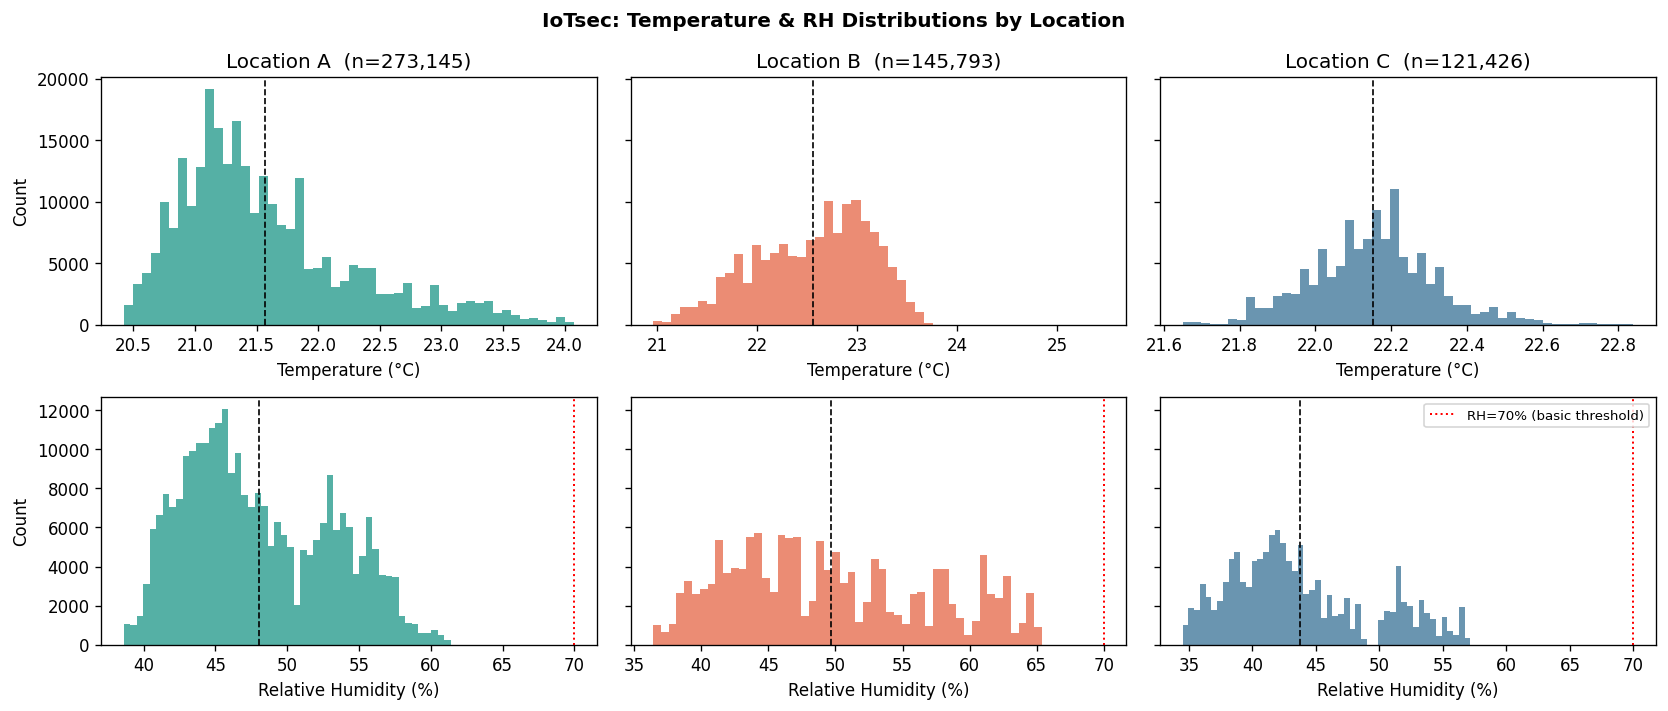

In [10]:
def parse_epw(path):
    """
    EPW files have 8 header rows then 8760 rows of hourly data.
    We extract columns: month, day, hour, dry_bulb_temp, dew_point,
    rel_humidity, atmospheric_pressure.
    """
    epw_cols = [
        "year","month","day","hour","minute",
        "data_source","dry_bulb_temp","dew_point_temp","rel_humidity",
        "atm_pressure","extraterr_horiz_rad","extraterr_direct_rad",
        "horiz_infrared_rad","global_horiz_rad","direct_normal_rad",
        "diffuse_horiz_rad","global_horiz_illum","direct_normal_illum",
        "diffuse_horiz_illum","zenith_luminance","wind_direction",
        "wind_speed","total_sky_cover","opaque_sky_cover","visibility",
        "ceiling_height","present_weather_obs","present_weather_codes",
        "precip_water","aerosol_opt_depth","snow_depth","days_since_snow",
        "albedo","liquid_precip_depth","liquid_precip_rate"
    ]
    df = pd.read_csv(path, skiprows=8, header=None,
                     names=epw_cols, usecols=range(len(epw_cols)))
    df["city"] = Path(path).stem
    return df[["city","month","day","hour",
               "dry_bulb_temp","dew_point_temp","rel_humidity","wind_speed"]]

epw_dfs = {f.stem[:20]: parse_epw(f) for f in epw_files}

for name, df in epw_dfs.items():
    print(f"\n{name[:40]}")
    print(f"  Rows: {len(df)}  |  "
          f"Temp: {df['dry_bulb_temp'].min():.0f}–"
          f"{df['dry_bulb_temp'].max():.0f}°C  |  "
          f"RH: {df['rel_humidity'].min():.0f}–"
          f"{df['rel_humidity'].max():.0f}%")

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey='row')
fig.suptitle("IoTsec: Temperature & RH Distributions by Location",
             fontsize=12, fontweight='bold')

colors = {'A': '#2a9d8f', 'B': '#e76f51', 'C': '#457b9d'}

for col, loc in enumerate(['A','B','C']):
    subset = iotsec_all[iotsec_all['location'] == loc]
    
    axes[0, col].hist(subset['Temp'].dropna(), bins=50,
                      color=colors[loc], alpha=0.8, edgecolor='none')
    axes[0, col].set_title(f"Location {loc}  (n={len(subset):,})")
    axes[0, col].set_xlabel("Temperature (°C)")
    axes[0, col].axvline(subset['Temp'].mean(), color='black',
                         linestyle='--', linewidth=1, label='mean')
    if col == 0:
        axes[0, col].set_ylabel("Count")

    axes[1, col].hist(subset['RelH'].dropna(), bins=50,
                      color=colors[loc], alpha=0.8, edgecolor='none')
    axes[1, col].set_xlabel("Relative Humidity (%)")
    axes[1, col].axvline(subset['RelH'].mean(), color='black',
                         linestyle='--', linewidth=1)
    axes[1, col].axvline(70, color='red', linestyle=':',
                         linewidth=1.2, label='RH=70% (basic threshold)')
    if col == 0:
        axes[1, col].set_ylabel("Count")
    if col == 2:
        axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_iotsec_distributions.png", dpi=150,
            bbox_inches='tight')
plt.show()

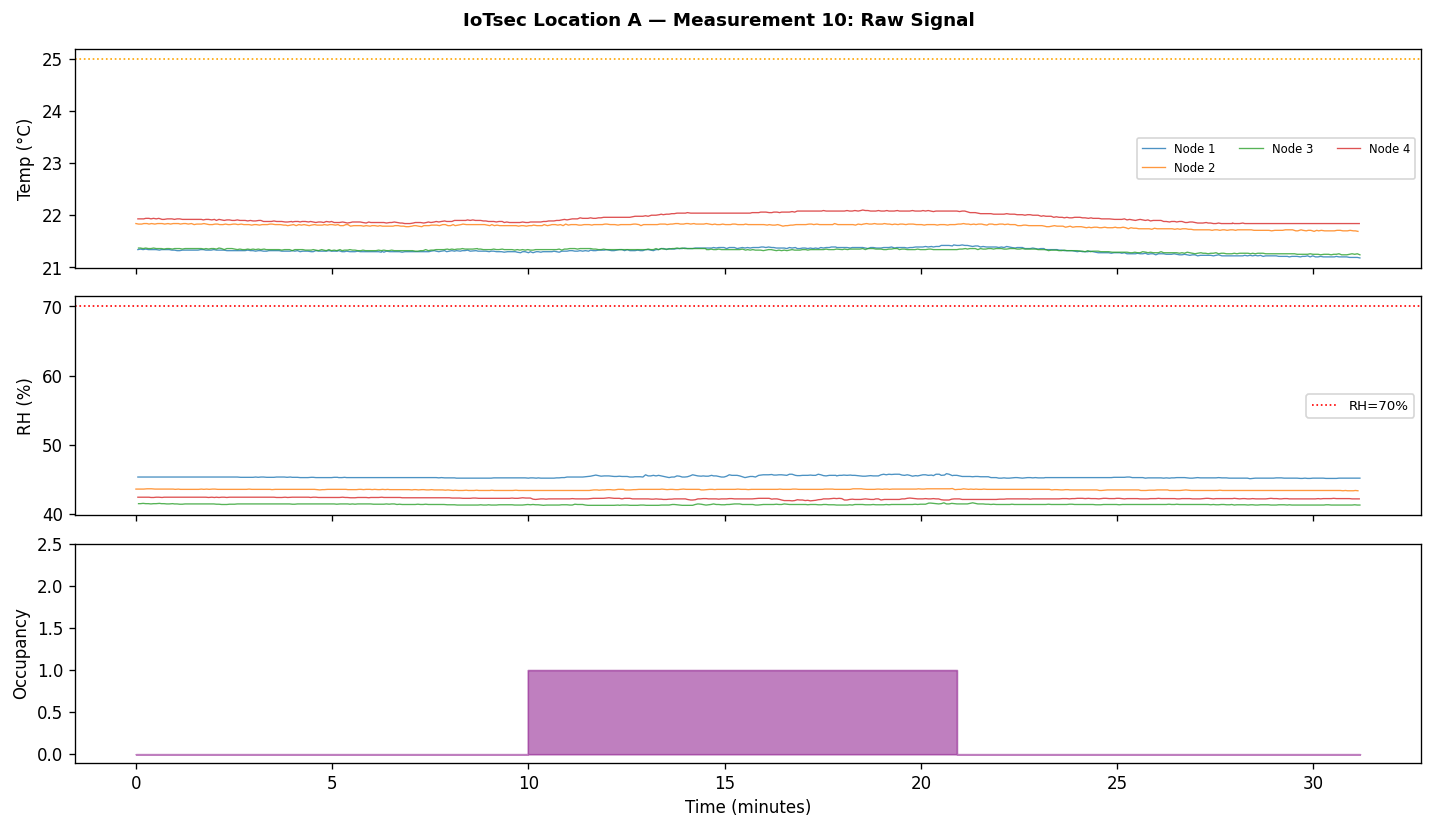

In [11]:
sample_m = pd.read_csv(
    ITS_DIR / "location_A" / "measurement10.csv",
    header=None,
    names=["EID","AbsT","RelT","NID","Temp","RelH",
           "L1","L2","Occ","Act","Door","Win"]
)

# Normalize time to minutes
sample_m['time_min'] = (sample_m['RelT'] - sample_m['RelT'].min()) / 60

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
fig.suptitle("IoTsec Location A — Measurement 10: Raw Signal",
             fontsize=11, fontweight='bold')

for nid, grp in sample_m.groupby('NID'):
    ax1.plot(grp['time_min'], grp['Temp'], linewidth=0.8, 
             alpha=0.8, label=f"Node {nid}")
    ax2.plot(grp['time_min'], grp['RelH'], linewidth=0.8, alpha=0.8)

ax1.set_ylabel("Temp (°C)")
ax1.legend(fontsize=7, ncol=3)
ax1.axhline(25, color='orange', linestyle=':', linewidth=1)

ax2.set_ylabel("RH (%)")
ax2.axhline(70, color='red', linestyle=':', linewidth=1,
            label='RH=70%')
ax2.legend(fontsize=8)

ax3.fill_between(sample_m['time_min'], sample_m['Occ'],
                 alpha=0.5, color='purple', step='post')
ax3.set_ylabel("Occupancy")
ax3.set_xlabel("Time (minutes)")
ax3.set_ylim(-0.1, 2.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_iotsec_timeseries.png", dpi=150,
            bbox_inches='tight')
plt.show()

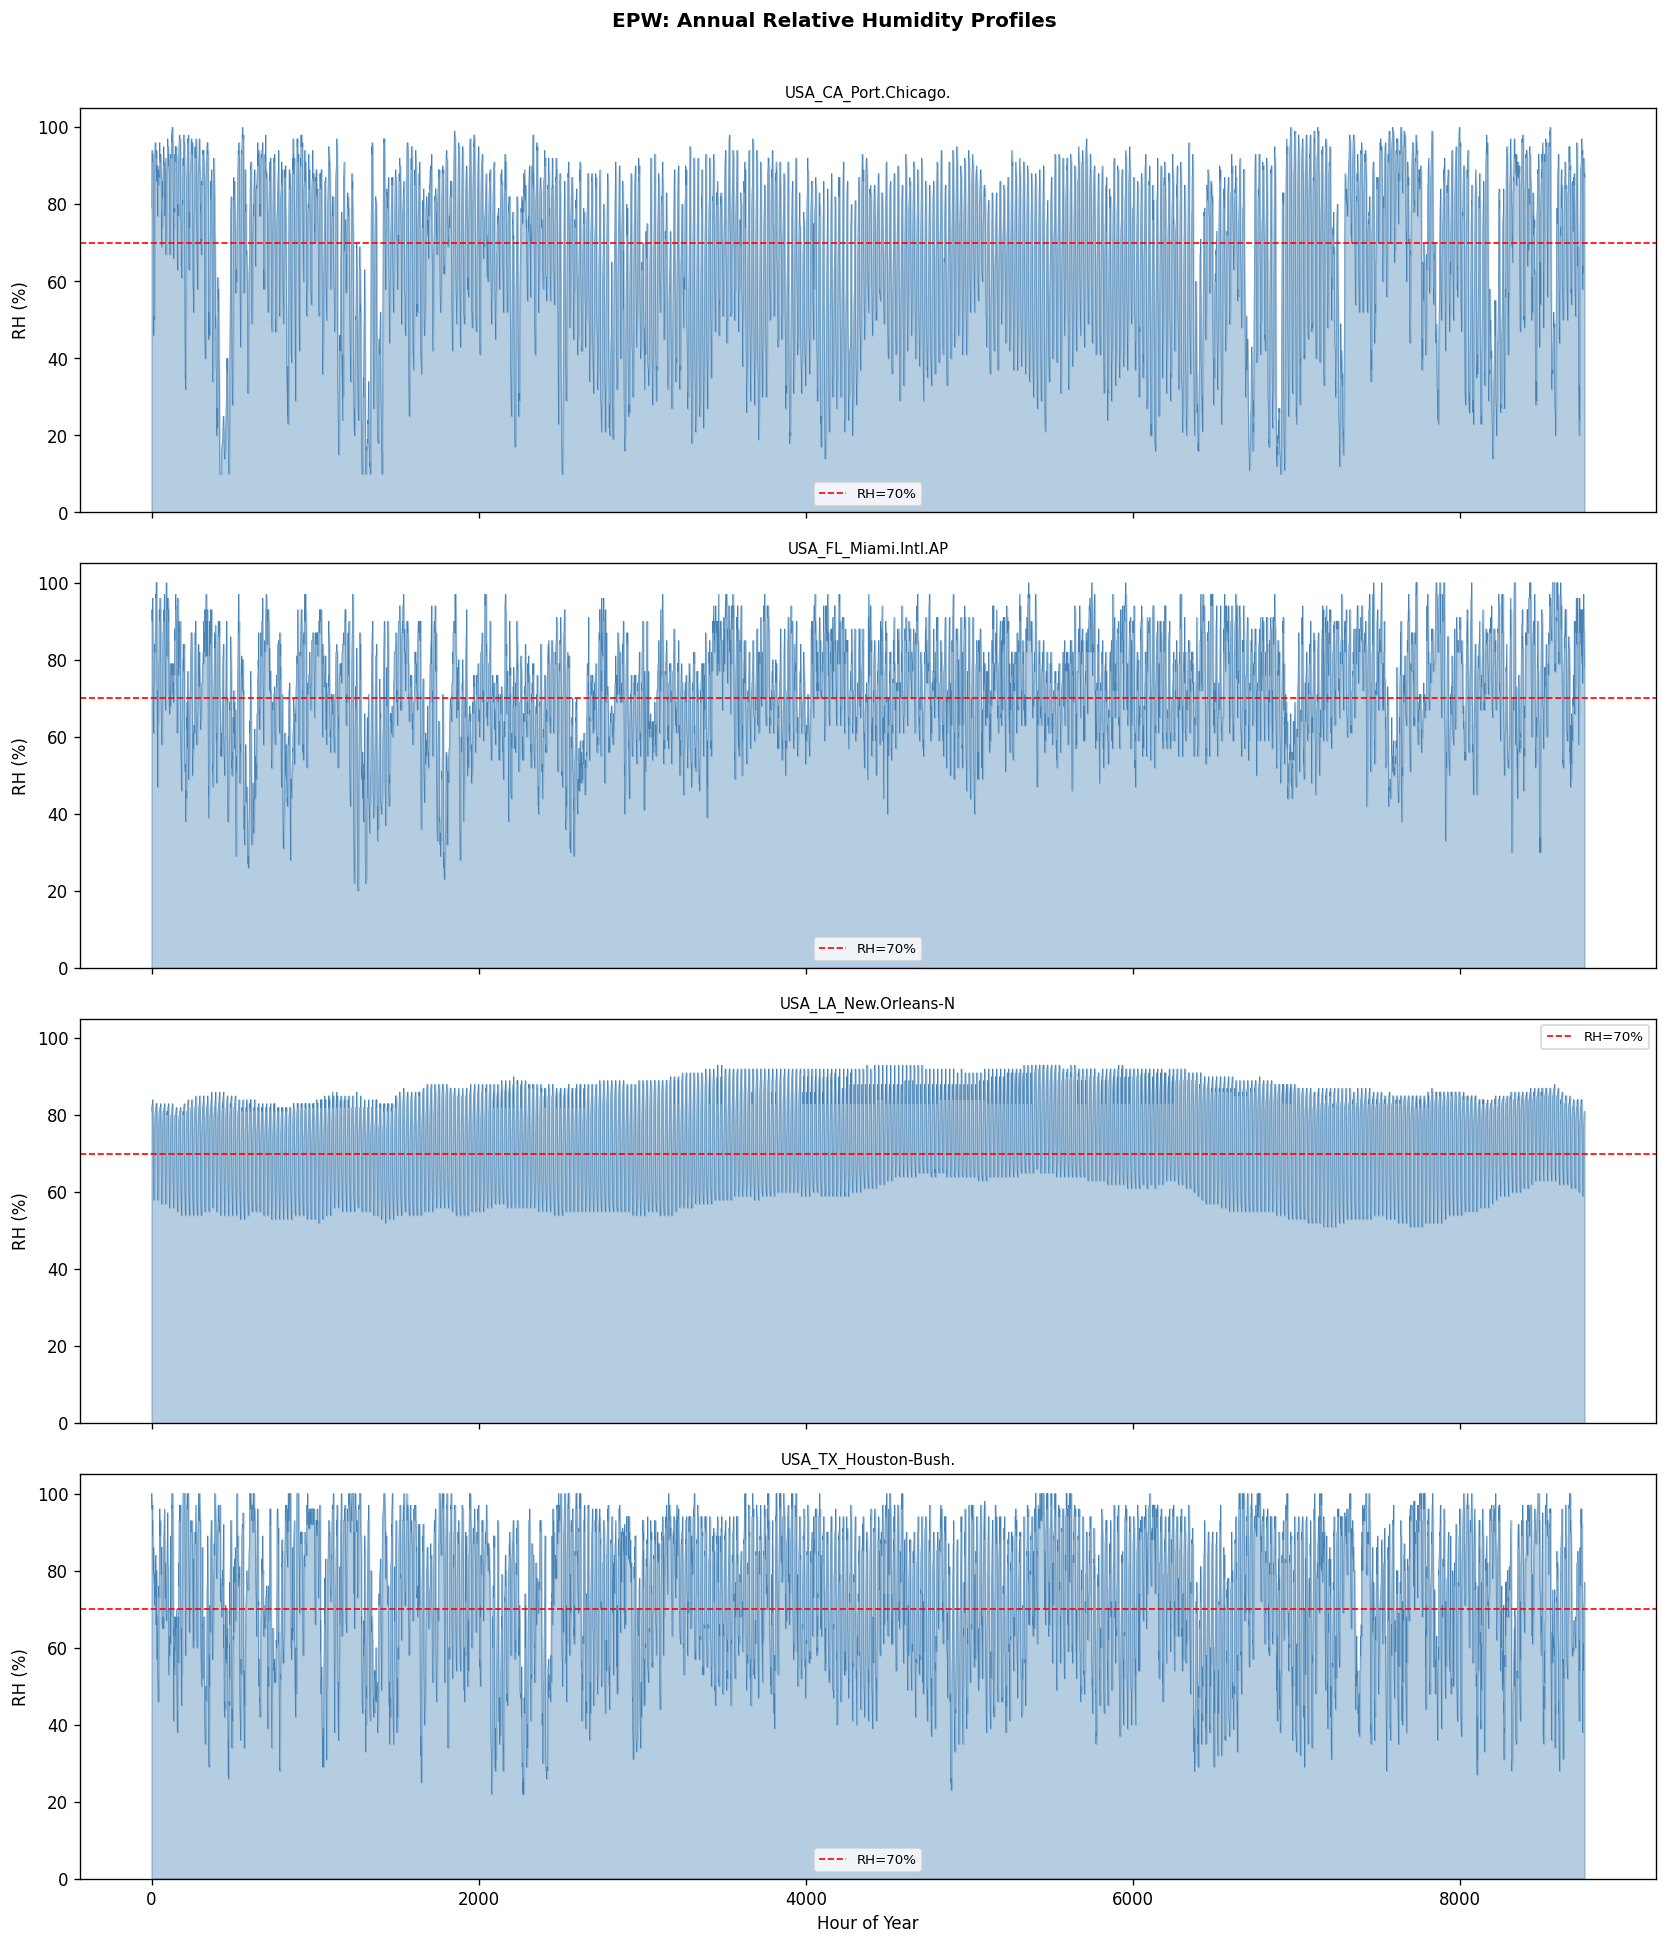

In [12]:
fig, axes = plt.subplots(len(epw_dfs), 1,
                         figsize=(14, 4 * len(epw_dfs)), sharex=True)
if len(epw_dfs) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, epw_dfs.items()):
    hours = np.arange(len(df))
    ax.fill_between(hours, df['rel_humidity'], alpha=0.4,
                    color='steelblue')
    ax.plot(hours, df['rel_humidity'], linewidth=0.3,
            color='steelblue')
    ax.axhline(70, color='red', linestyle='--',
               linewidth=1, label='RH=70%')
    ax.set_ylabel("RH (%)")
    ax.set_title(name[:50], fontsize=9)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Hour of Year")
fig.suptitle("EPW: Annual Relative Humidity Profiles",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_epw_rh_profiles.png", dpi=150,
            bbox_inches='tight')
plt.show()

In [13]:
import h5py

with h5py.File(RICO_DIR / "RICO_Acquisition_3_01-2024.hdf", "r") as f:
    print("Top-level keys:", list(f.keys()))
    
    # Recurse one level deeper
    for k in list(f.keys())[:3]:
        obj = f[k]
        print(f"\n  [{k}] → type: {type(obj).__name__}")
        if hasattr(obj, 'keys'):
            print(f"    Sub-keys: {list(obj.keys())[:10]}")
        if hasattr(obj, 'shape'):
            print(f"    Shape: {obj.shape}  Dtype: {obj.dtype}")
            if obj.dtype.names:
                print(f"    Columns: {list(obj.dtype.names)[:15]}")

Top-level keys: ['all']

  [all] → type: Group
    Sub-keys: ['axis0', 'axis1', 'block0_items', 'block0_values', 'block1_items', 'block1_values']


In [17]:
import pandas as pd

rico3 = pd.read_hdf(RICO_DIR / "RICO_Acquisition_3_01-2024.hdf", key="all")

print("Shape:", rico3.shape)
print("Index:", rico3.index[:5])
print("\nColumns:", list(rico3.columns[:20]))
print("\nDtypes:\n", rico3.dtypes.value_counts())
print("\nFirst 3 rows, first 6 cols:")
print(rico3.iloc[:3, :6])
print("\nBasic stats (first 5 cols):")
print(rico3.iloc[:, :5].describe())

# Print all columns so we can identify temp and RH sensors
for i, col in enumerate(rico3.columns):
    print(f"{i:3d}  {col}")

Shape: (5760, 82)
Index: DatetimeIndex(['2024-01-22 13:00:00+00:00', '2024-01-22 13:01:00+00:00',
               '2024-01-22 13:02:00+00:00', '2024-01-22 13:03:00+00:00',
               '2024-01-22 13:04:00+00:00'],
              dtype='datetime64[ns, tzutc()]', name='_time', freq='min')

Columns: ['Acquisition Phase', 'Scheduler Step', 'Flag', 'pid.EC3.setpoint', 'pid.SB43.setpoint', 'pid.SB46.setpoint', 'pid.SB47.setpoint', 'B.ASTRHT2.H', 'B.ASTRHT2.S', 'B.ASTRHT2.T', 'B.RTD1', 'B.RTD2', 'B.RTD3', 'B.RTD6', 'BT.AOC', 'BT.AOE', 'BT.AOF', 'BT.AON', 'BT.AOW', 'BT.SIC_25']

Dtypes:
 float64    71
int64      11
Name: count, dtype: int64

First 3 rows, first 6 cols:
Index                      Acquisition Phase  Scheduler Step  Flag  \
_time                                                                
2024-01-22 13:00:00+00:00                  3               0     0   
2024-01-22 13:01:00+00:00                  3               0     0   
2024-01-22 13:02:00+00:00                  3     

In [18]:
key_cols = [
    'WS1_Temperature', 'WS1_Relative_humidity',
    'B.RTD1', 'B.RTD2', 'B.RTD3',
    'BT.AOC', 'BT.AOE', 'BT.AON', 'BT.AOW',
    'BT.SIC_25', 'BT.SIE_7', 'BT.SIN_17', 'BT.SIW_7',
    'BT.SOC', 'BT.SOE', 'BT.SON', 'BT.SOW',
    'RTD410.T', 'RTD508', 'RTD509'
]

print(f"{'Column':<25} {'Min':>7} {'Max':>7} {'Mean':>7} {'NaN':>6}")
print("-" * 58)
for col in key_cols:
    if col in rico3.columns:
        s = rico3[col]
        print(f"{col:<25} {s.min():>7.2f} {s.max():>7.2f} "
              f"{s.mean():>7.2f} {s.isna().sum():>6}")

Column                        Min     Max    Mean    NaN
----------------------------------------------------------
WS1_Temperature             -0.90    7.40    3.58      0
WS1_Relative_humidity       50.90  100.00   84.51      0
B.RTD1                      14.30   30.70   19.90      0
B.RTD2                      14.20   31.80   20.14      0
B.RTD3                      14.20   32.40   20.26      0
BT.AOC                      21.60   24.50   22.44      0
BT.AOE                      21.80   24.00   22.54      0
BT.AON                      21.90   24.00   22.57      0
BT.AOW                      21.80   24.20   22.58      0
BT.SIC_25                   15.00   34.10   21.40      0
BT.SIE_7                    12.00   33.30   19.32      0
BT.SIN_17                   14.80   32.90   20.65      0
BT.SIW_7                    14.80   32.50   20.66      0
BT.SOC                      21.50   24.60   22.44      0
BT.SOE                      21.80   24.20   22.59      0
BT.SON                      2

In [15]:
print("=" * 55)
print("  DATASET SUMMARY")
print("=" * 55)

print("\n── IoTsec ──────────────────────────────────────")
for loc in ['A','B','C']:
    s = iotsec_all[iotsec_all['location'] == loc]
    print(f"  Location {loc}: {len(s):>7,} rows | "
          f"Temp {s['Temp'].mean():.1f}°C avg | "
          f"RH {s['RelH'].mean():.1f}% avg")

print("\n── EPW ─────────────────────────────────────────")
for name, df in epw_dfs.items():
    pct_above = (df['rel_humidity'] > 70).mean() * 100
    print(f"  {name[:35]:<35} | "
          f"RH>70%: {pct_above:.1f}% of year")

print("\n── RICO ────────────────────────────────────────")
for f in rico_files:
    with h5py.File(f, 'r') as hf:
        n = len(hf.keys())
    print(f"  {f.name:<45} | {n} trials")

print("=" * 55)
print("\nNotebook 1 complete. Figures saved to /figures/")

  DATASET SUMMARY

── IoTsec ──────────────────────────────────────
  Location A: 273,145 rows | Temp 21.6°C avg | RH 48.0% avg
  Location B: 145,793 rows | Temp 22.6°C avg | RH 49.7% avg
  Location C: 121,426 rows | Temp 22.2°C avg | RH 43.7% avg

── EPW ─────────────────────────────────────────
  USA_CA_Port.Chicago.                | RH>70%: 50.5% of year
  USA_FL_Miami.Intl.AP                | RH>70%: 57.4% of year
  USA_LA_New.Orleans-N                | RH>70%: 62.9% of year
  USA_TX_Houston-Bush.                | RH>70%: 61.7% of year

── RICO ────────────────────────────────────────
  RICO_Acquisition_1_07-2023.hdf                | 1 trials
  RICO_Acquisition_2_10-2023.hdf                | 1 trials
  RICO_Acquisition_3_01-2024.hdf                | 1 trials
  RICO_Acquisition_4_02-2024.hdf                | 1 trials
  RICO_Acquisition_5_05-2024.hdf                | 1 trials

Notebook 1 complete. Figures saved to /figures/


In [16]:
processed_dir = BASE / "data/processed"
processed_dir.mkdir(exist_ok=True)

iotsec_all.to_parquet(processed_dir / "iotsec_all.parquet", index=False)
print(f"Saved iotsec_all.parquet  ({len(iotsec_all):,} rows)")
print("Ready for Notebook 2.")

Saved iotsec_all.parquet  (540,364 rows)
Ready for Notebook 2.
